# Customer Personality Segmentation - Complete Analysis
## End-to-End Machine Learning Pipeline

This notebook performs comprehensive customer segmentation analysis including:
1. **Data Preprocessing & Feature Engineering**
2. **Unsupervised Learning (Clustering)**
3. **Supervised Learning (Classification)**
4. **Advanced Visualizations**

---

## 📦 Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Machine Learning - Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage

# Machine Learning - Classification
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Metrics
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    classification_report, confusion_matrix, accuracy_score, 
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

# Utilities
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visualization styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---
# Part 1: Data Preprocessing & Feature Engineering
---

## 1.1 Load Data

In [2]:
# Load dataset
df = pd.read_csv('marketing_campaign_v.csv', sep='\t')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset Shape: (2240, 28)

Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,4,7,0,0,0,0,0,0,3,11
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,5,0,0,0,0,0,0,3,11
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,10,4,0,0,0,0,0,0,3,11
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,4,6,0,0,0,0,0,0,3,11
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,6,5,0,0,0,0,0,0,3,11


## 1.2 Data Exploration

In [3]:
# Basic information
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Statistical Summary:")
df.describe()

Data Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
dtype: object

Missing Values:
ID                      0
Year_Birth              0
Education               0
Marital_Sta

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0


## 1.3 Handle Missing Values

In [4]:
# Fill missing Income with median
if df['Income'].isnull().sum() > 0:
    median_income = df['Income'].median()
    df['Income'].fillna(median_income, inplace=True)
    print(f"✓ Filled missing Income values with median: {median_income:.2f}")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

✓ Filled missing Income values with median: 51381.50

Remaining missing values: 0


## 1.4 Feature Engineering

In [5]:
# Create new features
current_year = 2024

# 1. Age from Year_Birth
df['Age'] = current_year - df['Year_Birth']

# 2. Total Spending
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)

# 3. Total Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# 4. Family Size
df['Family_Size'] = df['Total_Children'] + 1
df.loc[df['Marital_Status'].isin(['Married', 'Together']), 'Family_Size'] += 1

# 5. Is Parent
df['Is_Parent'] = (df['Total_Children'] > 0).astype(int)

# 6. Total Purchases
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# 7. Total Campaigns Accepted
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
                'AcceptedCmp4', 'AcceptedCmp5']
df['Total_Campaigns_Accepted'] = df[campaign_cols].sum(axis=1)

# 8. Customer Tenure
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
reference_date = df['Dt_Customer'].max()
df['Customer_Days'] = (reference_date - df['Dt_Customer']).dt.days

# 9. Average Purchase Value
df['Avg_Purchase_Value'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)

# 10. Spending per Day
df['Spending_Per_Day'] = df['Total_Spending'] / (df['Customer_Days'] + 1)

# 11. Income per Family Member
df['Income_Per_Member'] = df['Income'] / df['Family_Size']

# 12. Education Level (Ordinal)
education_map = {'Basic': 1, '2n Cycle': 2, 'Graduation': 3, 'Master': 4, 'PhD': 5}
df['Education_Level'] = df['Education'].map(education_map)

# 13. Has Partner
df['Has_Partner'] = df['Marital_Status'].isin(['Married', 'Together']).astype(int)

# 14. Web Activity Score
df['Web_Activity_Score'] = (df['NumWebPurchases'] * 2 + df['NumWebVisitsMonth']) / 3

# 15. Deal Sensitivity
df['Deal_Sensitivity'] = df['NumDealsPurchases'] / (df['Total_Purchases'] + 1)

# 16. Product Diversity
df['Product_Diversity'] = (df[spending_cols] > 0).sum(axis=1)

# 17. Response Rate
df['Response_Rate'] = df['Total_Campaigns_Accepted'] / 5

print(f"✓ Created 17 new features")
print(f"New dataset shape: {df.shape}")

✓ Created 17 new features
New dataset shape: (2240, 45)


## 1.5 Remove Outliers

In [6]:
# Remove extreme outliers
initial_rows = len(df)

# Age outliers
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

# Income outliers (1st and 99th percentile)
Q1 = df['Income'].quantile(0.01)
Q3 = df['Income'].quantile(0.99)
df = df[(df['Income'] >= Q1) & (df['Income'] <= Q3)]

# Spending outliers
Q1_spend = df['Total_Spending'].quantile(0.01)
Q3_spend = df['Total_Spending'].quantile(0.99)
df = df[(df['Total_Spending'] >= Q1_spend) & (df['Total_Spending'] <= Q3_spend)]

removed_rows = initial_rows - len(df)
print(f"Removed {removed_rows} outlier rows ({removed_rows/initial_rows*100:.2f}%)")
print(f"Remaining rows: {len(df)}")

Removed 91 outlier rows (4.06%)
Remaining rows: 2149


## 1.6 Visualize Key Features

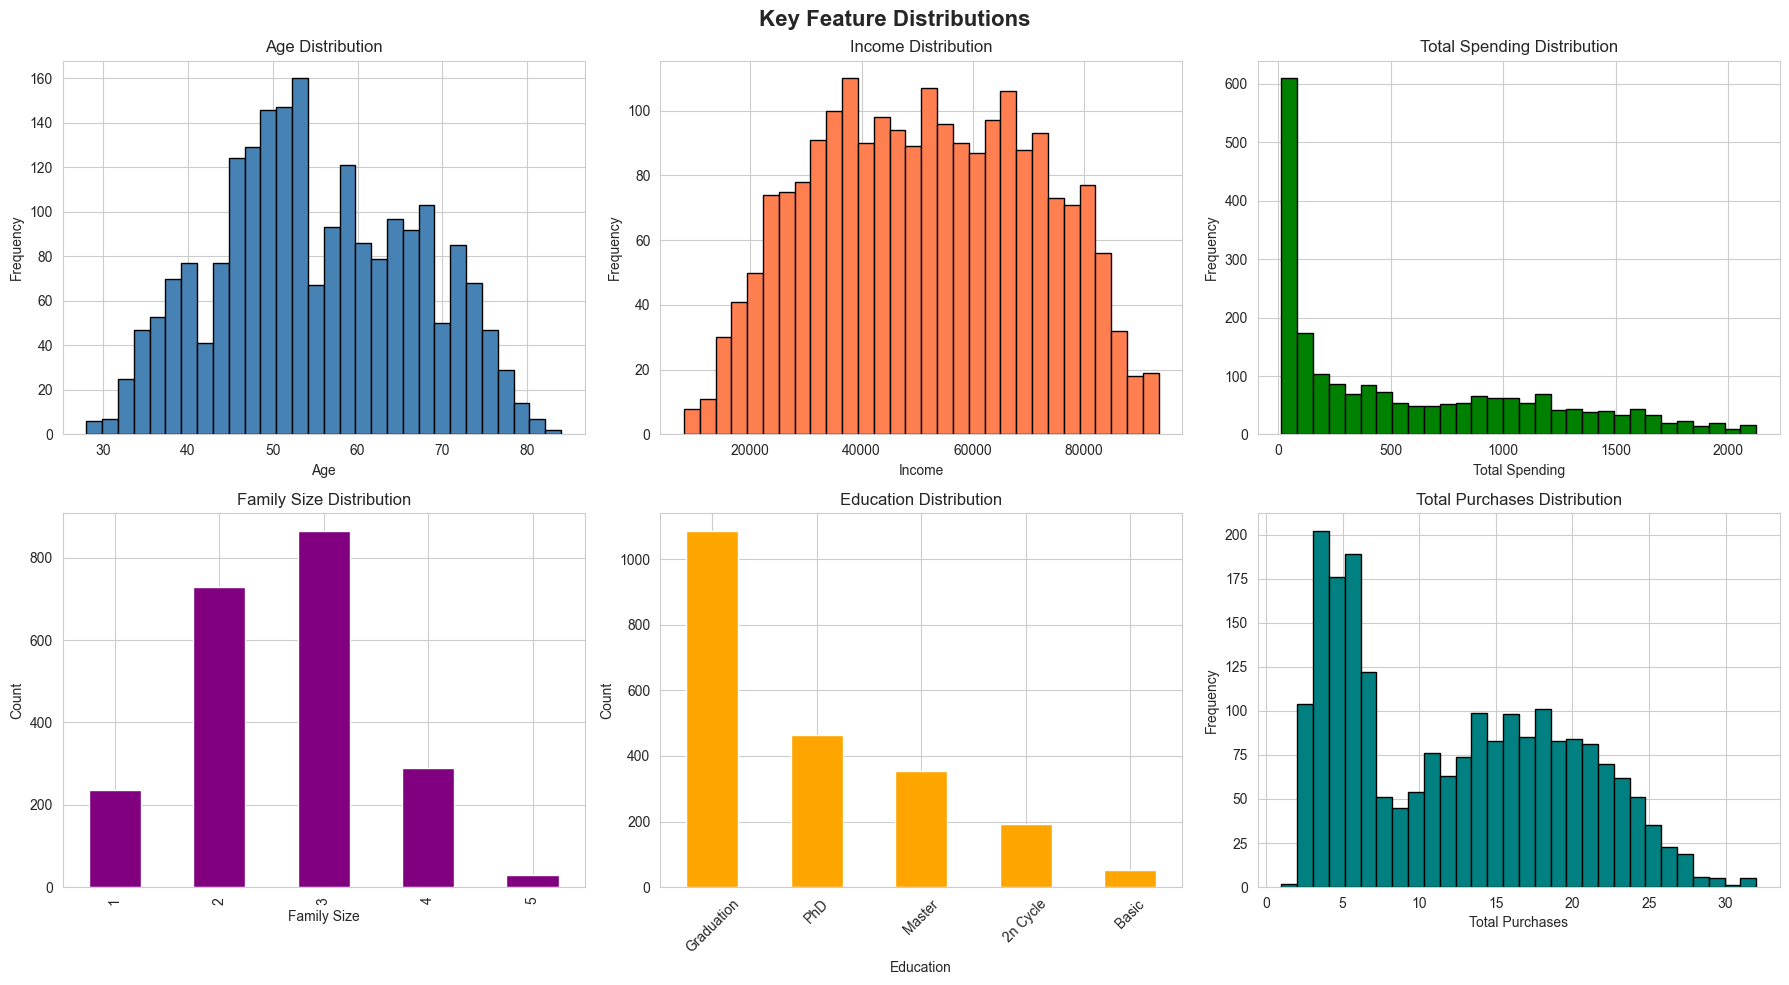

In [7]:
# Create visualization of key features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Feature Distributions', fontsize=16, fontweight='bold')

# Age
axes[0, 0].hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Income
axes[0, 1].hist(df['Income'], bins=30, color='coral', edgecolor='black')
axes[0, 1].set_title('Income Distribution')
axes[0, 1].set_xlabel('Income')
axes[0, 1].set_ylabel('Frequency')

# Total Spending
axes[0, 2].hist(df['Total_Spending'], bins=30, color='green', edgecolor='black')
axes[0, 2].set_title('Total Spending Distribution')
axes[0, 2].set_xlabel('Total Spending')
axes[0, 2].set_ylabel('Frequency')

# Family Size
df['Family_Size'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Family Size Distribution')
axes[1, 0].set_xlabel('Family Size')
axes[1, 0].set_ylabel('Count')

# Education Level
df['Education'].value_counts().plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Education Distribution')
axes[1, 1].set_xlabel('Education')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

# Total Purchases
axes[1, 2].hist(df['Total_Purchases'], bins=30, color='teal', edgecolor='black')
axes[1, 2].set_title('Total Purchases Distribution')
axes[1, 2].set_xlabel('Total Purchases')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---
# Part 2: Unsupervised Learning (Clustering)
---

## 2.1 Prepare Features for Clustering

In [8]:
# Select numerical features for clustering
clustering_features = [
    'Age', 'Income', 'Total_Spending', 'Total_Children',
    'Family_Size', 'Total_Purchases', 'Customer_Days',
    'Avg_Purchase_Value', 'Spending_Per_Day', 'Income_Per_Member',
    'Education_Level', 'Has_Partner', 'Total_Campaigns_Accepted',
    'Web_Activity_Score', 'Deal_Sensitivity', 'Product_Diversity',
    'Response_Rate', 'Recency', 'NumWebVisitsMonth',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

# Filter available features
available_features = [f for f in clustering_features if f in df.columns]
X = df[available_features].copy()
X = X.fillna(X.median())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✓ Features prepared: {X_scaled.shape}")
print(f"✓ Using {len(available_features)} features for clustering")

✓ Features prepared: (2149, 25)
✓ Using 25 features for clustering


## 2.2 Principal Component Analysis (PCA)

Original dimensions: 25
Reduced dimensions: 16
Explained variance: 0.9536


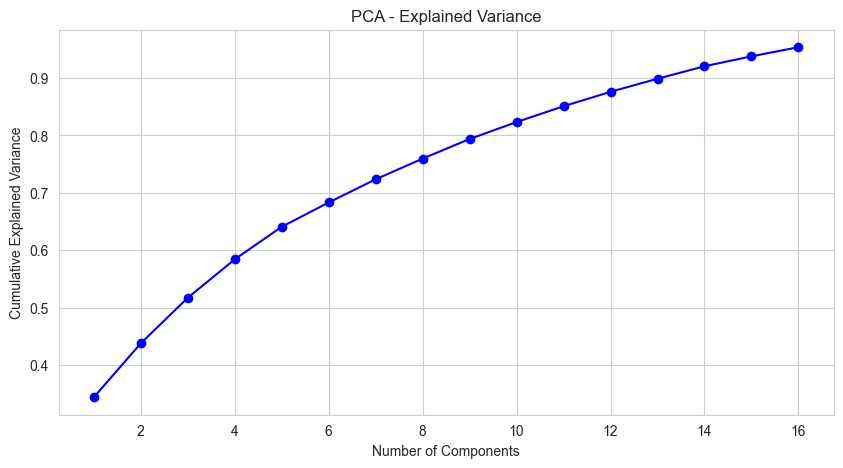

In [9]:
# Perform PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Reduced dimensions: {X_pca.shape[1]}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")

# Plot explained variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
        np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.grid(True)
plt.show()

## 2.3 Find Optimal Number of Clusters

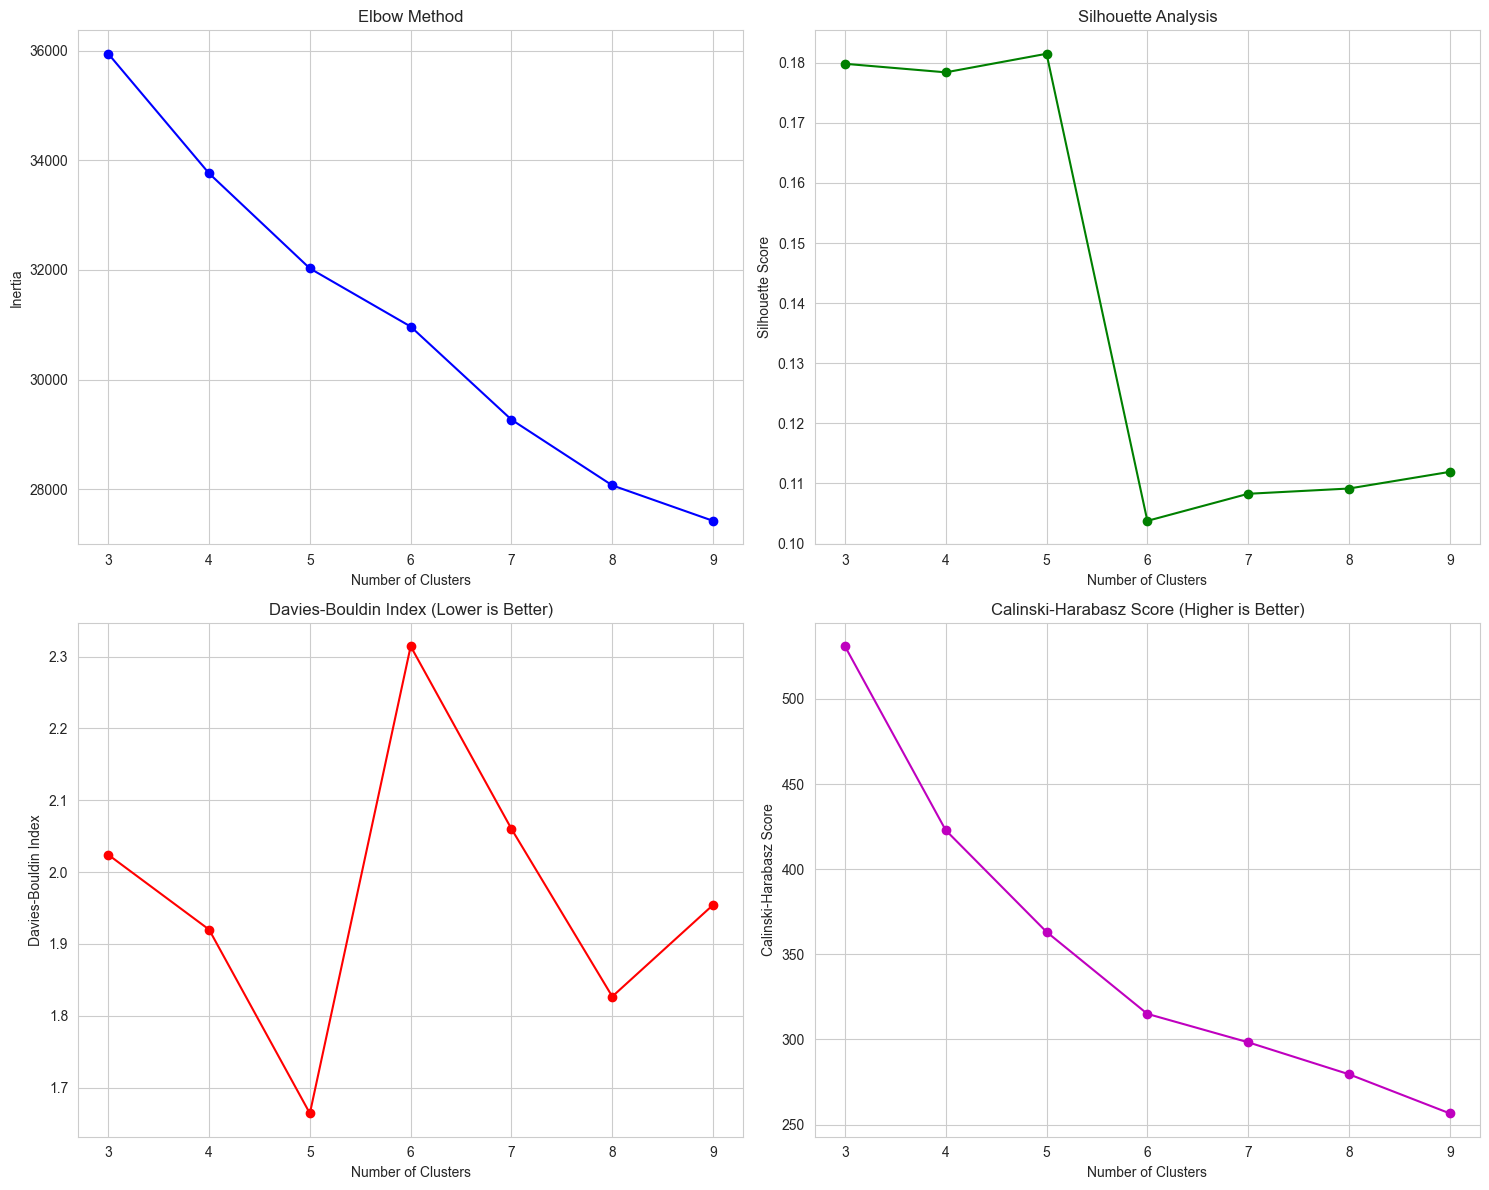


✓ Optimal number of clusters: 3 (fixed)
  Silhouette Score for k=3: 0.1798


In [10]:
# Find optimal clusters using multiple methods
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

K_range = range(3, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled, labels))

# Plot metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].plot(K_range, inertias, 'bo-')
axes[0, 0].set_xlabel('Number of Clusters')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True)

axes[0, 1].plot(K_range, silhouette_scores, 'go-')
axes[0, 1].set_xlabel('Number of Clusters')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Analysis')
axes[0, 1].grid(True)

axes[1, 0].plot(K_range, davies_bouldin_scores, 'ro-')
axes[1, 0].set_xlabel('Number of Clusters')
axes[1, 0].set_ylabel('Davies-Bouldin Index')
axes[1, 0].set_title('Davies-Bouldin Index (Lower is Better)')
axes[1, 0].grid(True)

axes[1, 1].plot(K_range, calinski_harabasz_scores, 'mo-')
axes[1, 1].set_xlabel('Number of Clusters')
axes[1, 1].set_ylabel('Calinski-Harabasz Score')
axes[1, 1].set_title('Calinski-Harabasz Score (Higher is Better)')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

best_k = 3  # Fixed to 3 clusters
print(f"\n✓ Optimal number of clusters: {best_k} (fixed)")
print(f"  Silhouette Score for k={best_k}: {silhouette_scores[list(K_range).index(best_k)]:.4f}")

## 2.4 Perform K-Means Clustering

In [11]:
# Perform K-Means with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels

# Calculate metrics
silhouette = silhouette_score(X_scaled, cluster_labels)
davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)
calinski_harabasz = calinski_harabasz_score(X_scaled, cluster_labels)

print(f"K-Means Clustering Results:")
print(f"  Number of clusters: {best_k}")
print(f"  Silhouette Score: {silhouette:.4f}")
print(f"  Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Score: {calinski_harabasz:.4f}")
print(f"\nCluster Sizes:")
print(df['Cluster'].value_counts().sort_index())

K-Means Clustering Results:
  Number of clusters: 3
  Silhouette Score: 0.1798
  Davies-Bouldin Index: 2.0241
  Calinski-Harabasz Score: 530.9526

Cluster Sizes:
Cluster
0     623
1    1059
2     467
Name: count, dtype: int64


## 2.5 Visualize Clusters

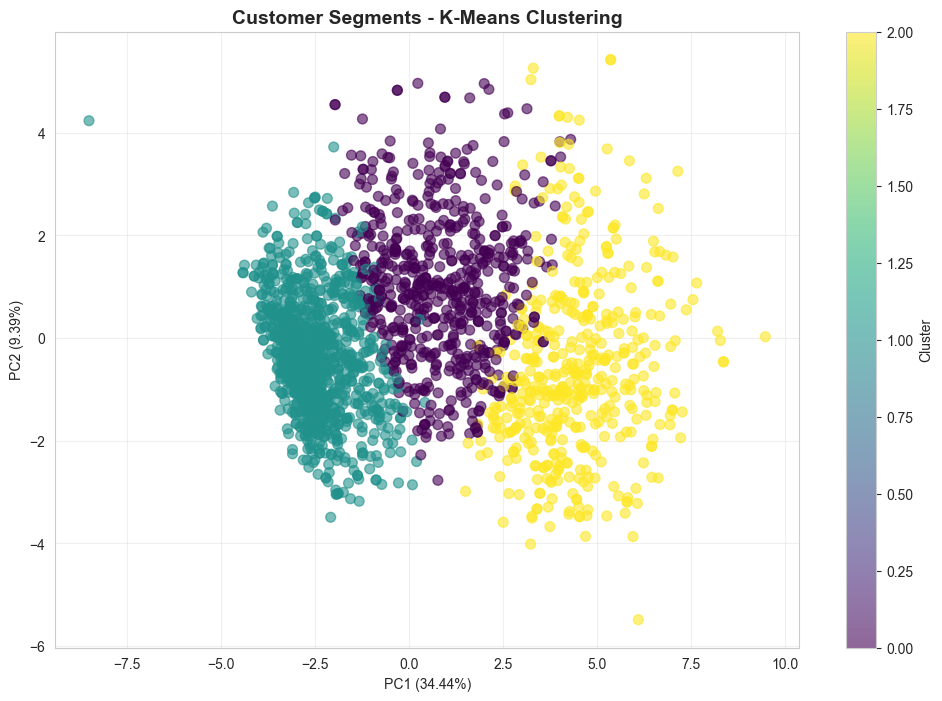

In [12]:
# Visualize clusters using first 2 PCA components
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, 
                     cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.title('Customer Segments - K-Means Clustering', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

## 2.6 Cluster Profiling

Cluster Profiles (Mean Values):
           Age    Income  Total_Spending  Total_Children  Education_Level  \
Cluster                                                                     
0        58.49  59602.80          809.55            1.05             3.64   
1        53.05  36287.42          113.61            1.27             3.34   
2        55.63  76028.60         1391.46            0.13             3.47   

         Total_Purchases  Response_Rate  Product_Diversity  Deal_Sensitivity  
Cluster                                                                       
0                  18.29           0.05               5.53              0.19  
1                   6.37           0.02               5.22              0.30  
2                  18.97           0.15               5.81              0.06  


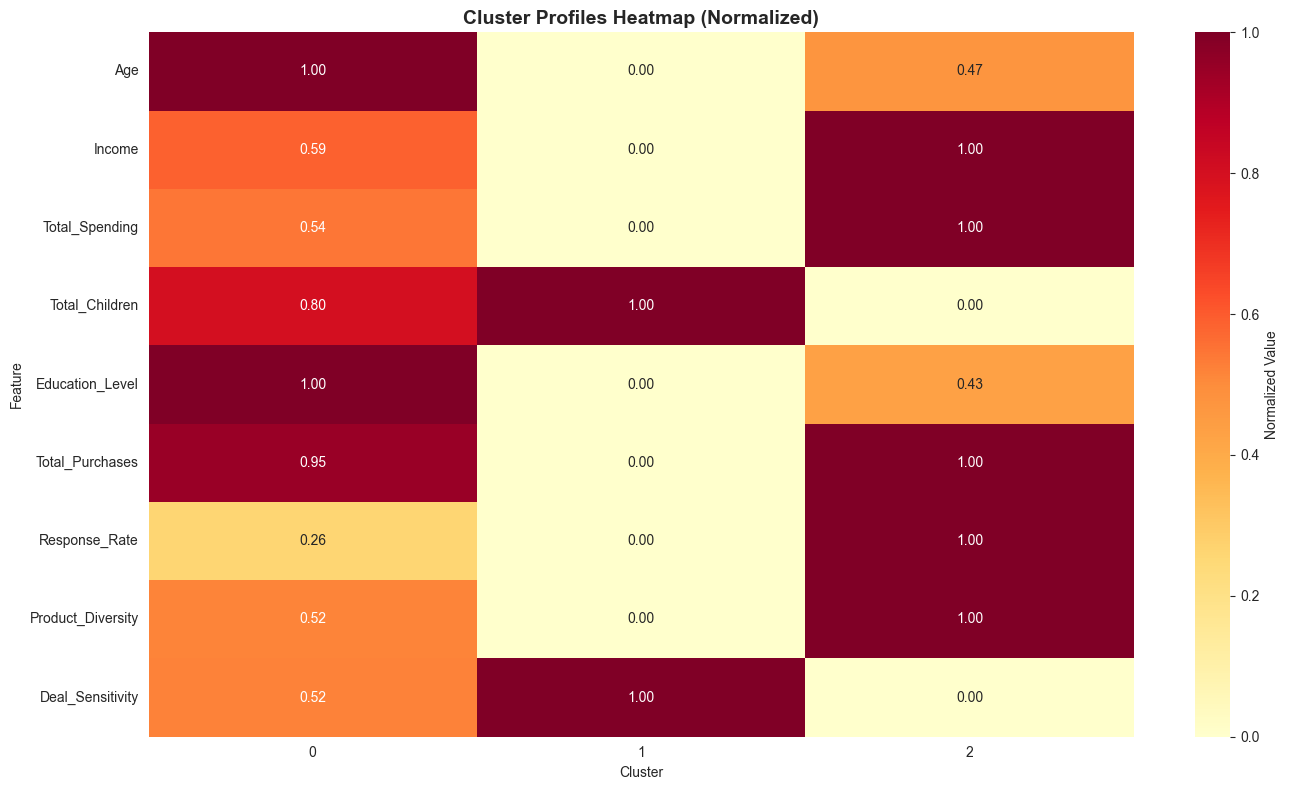

In [13]:
# Analyze cluster characteristics
profile_features = [
    'Age', 'Income', 'Total_Spending', 'Total_Children',
    'Education_Level', 'Total_Purchases', 'Response_Rate',
    'Product_Diversity', 'Deal_Sensitivity'
]

available_profile = [f for f in profile_features if f in df.columns]
cluster_profiles = df.groupby('Cluster')[available_profile].mean()

print("Cluster Profiles (Mean Values):")
print(cluster_profiles.round(2))

# Visualize cluster profiles
cluster_profiles_normalized = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles_normalized.T, annot=True, fmt='.2f', 
           cmap='YlOrRd', cbar_kws={'label': 'Normalized Value'})
plt.title('Cluster Profiles Heatmap (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---
# Part 3: Supervised Learning (Classification)
---

## 3.1 Prepare Data for Classification

In [14]:
# Prepare features and target
feature_cols = available_features
X = df[feature_cols].copy()
y = df['Cluster'].copy()

X = X.fillna(X.median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler_supervised = StandardScaler()
X_train_scaled = scaler_supervised.fit_transform(X_train)
X_test_scaled = scaler_supervised.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"\nClass distribution:")
print(y.value_counts().sort_index())

Training set: (1719, 25)
Test set: (430, 25)
Number of classes: 3

Class distribution:
Cluster
0     623
1    1059
2     467
Name: count, dtype: int64


## 3.2 Train Multiple Classification Models

In [15]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42)
}

results = []

print("Training models...\n")
for name, model in models.items():
    print(f"Training {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
    print(f"  Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
results_df

Training models...

Training Logistic Regression...
  Accuracy: 0.9907, F1-Score: 0.9907
Training Decision Tree...
  Accuracy: 0.9419, F1-Score: 0.9419
Training Random Forest...
  Accuracy: 0.9721, F1-Score: 0.9723
Training Gradient Boosting...
  Accuracy: 0.9698, F1-Score: 0.9700
Training K-Nearest Neighbors...
  Accuracy: 0.9442, F1-Score: 0.9438
Training Support Vector Machine...
  Accuracy: 0.9721, F1-Score: 0.9722

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Logistic Regression,0.990698,0.990698,0.990698,0.990698,0.983718,0.009115
2,Random Forest,0.972093,0.973326,0.972093,0.972259,0.953451,0.011684
5,Support Vector Machine,0.972093,0.972559,0.972093,0.972198,0.976144,0.012125
3,Gradient Boosting,0.969767,0.971277,0.969767,0.970019,0.965091,0.008249
4,K-Nearest Neighbors,0.944186,0.944289,0.944186,0.943806,0.936586,0.011279
1,Decision Tree,0.941860,0.942838,0.941860,0.941935,0.927271,0.010666


## 3.3 Visualize Model Comparison

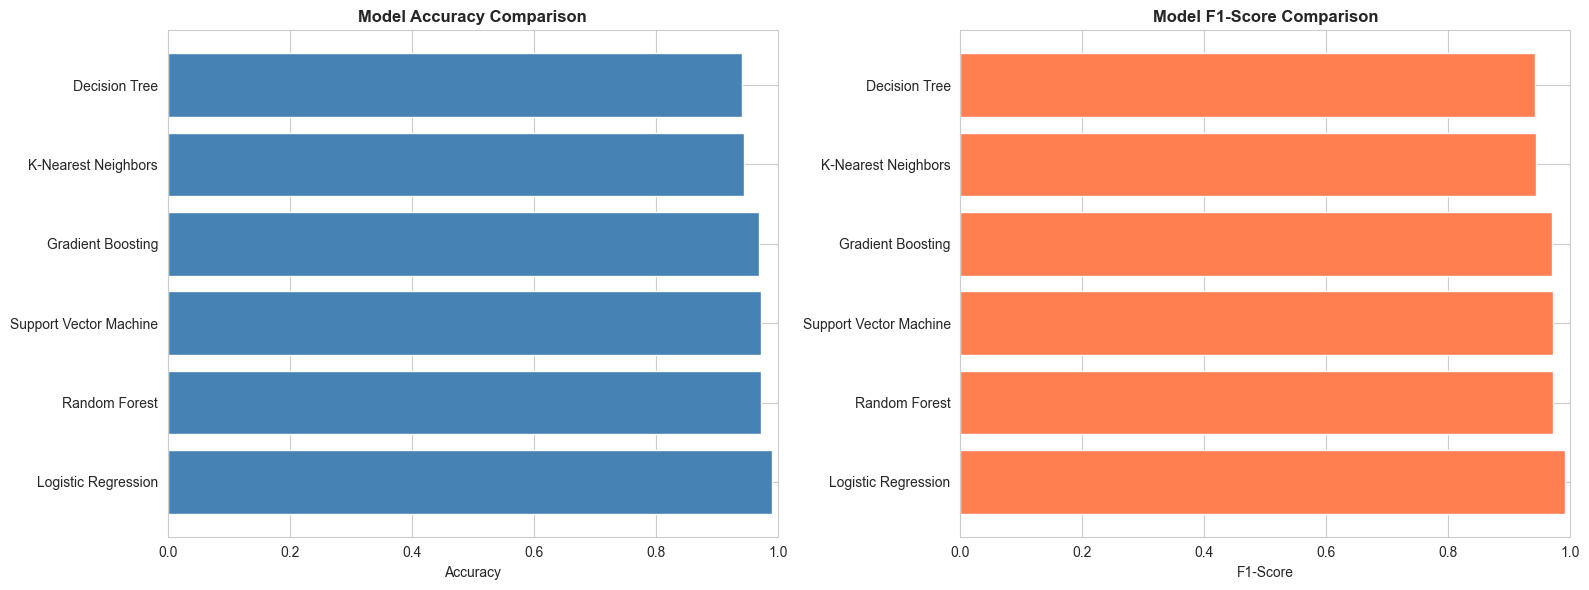

In [16]:
# Plot model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
axes[0].barh(results_df['Model'], results_df['Accuracy'], color='steelblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_xlim([0, 1])

# F1-Score comparison
axes[1].barh(results_df['Model'], results_df['F1-Score'], color='coral')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Model F1-Score Comparison', fontweight='bold')
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()

## 3.4 Evaluate Best Model

Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       125
           1       1.00      1.00      1.00       212
           2       0.99      0.99      0.99        93

    accuracy                           0.99       430
   macro avg       0.99      0.99      0.99       430
weighted avg       0.99      0.99      0.99       430



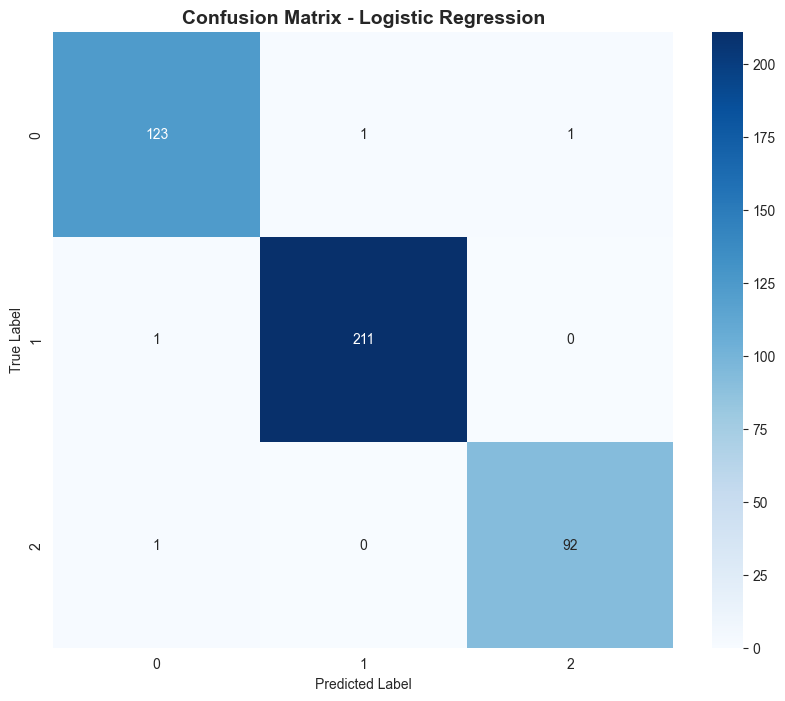

In [17]:
# Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"\nClassification Report:")

y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 3.5 Feature Importance

In [18]:
# Plot feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]
    
    plt.figure(figsize=(12, 8))
    plt.title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
    plt.barh(range(len(indices)), importances[indices], color='steelblue')
    plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not have feature_importances_ attribute")

Logistic Regression does not have feature_importances_ attribute


---
# Part 4: Advanced Visualizations
---

## 4.1 Cluster Overview Dashboard

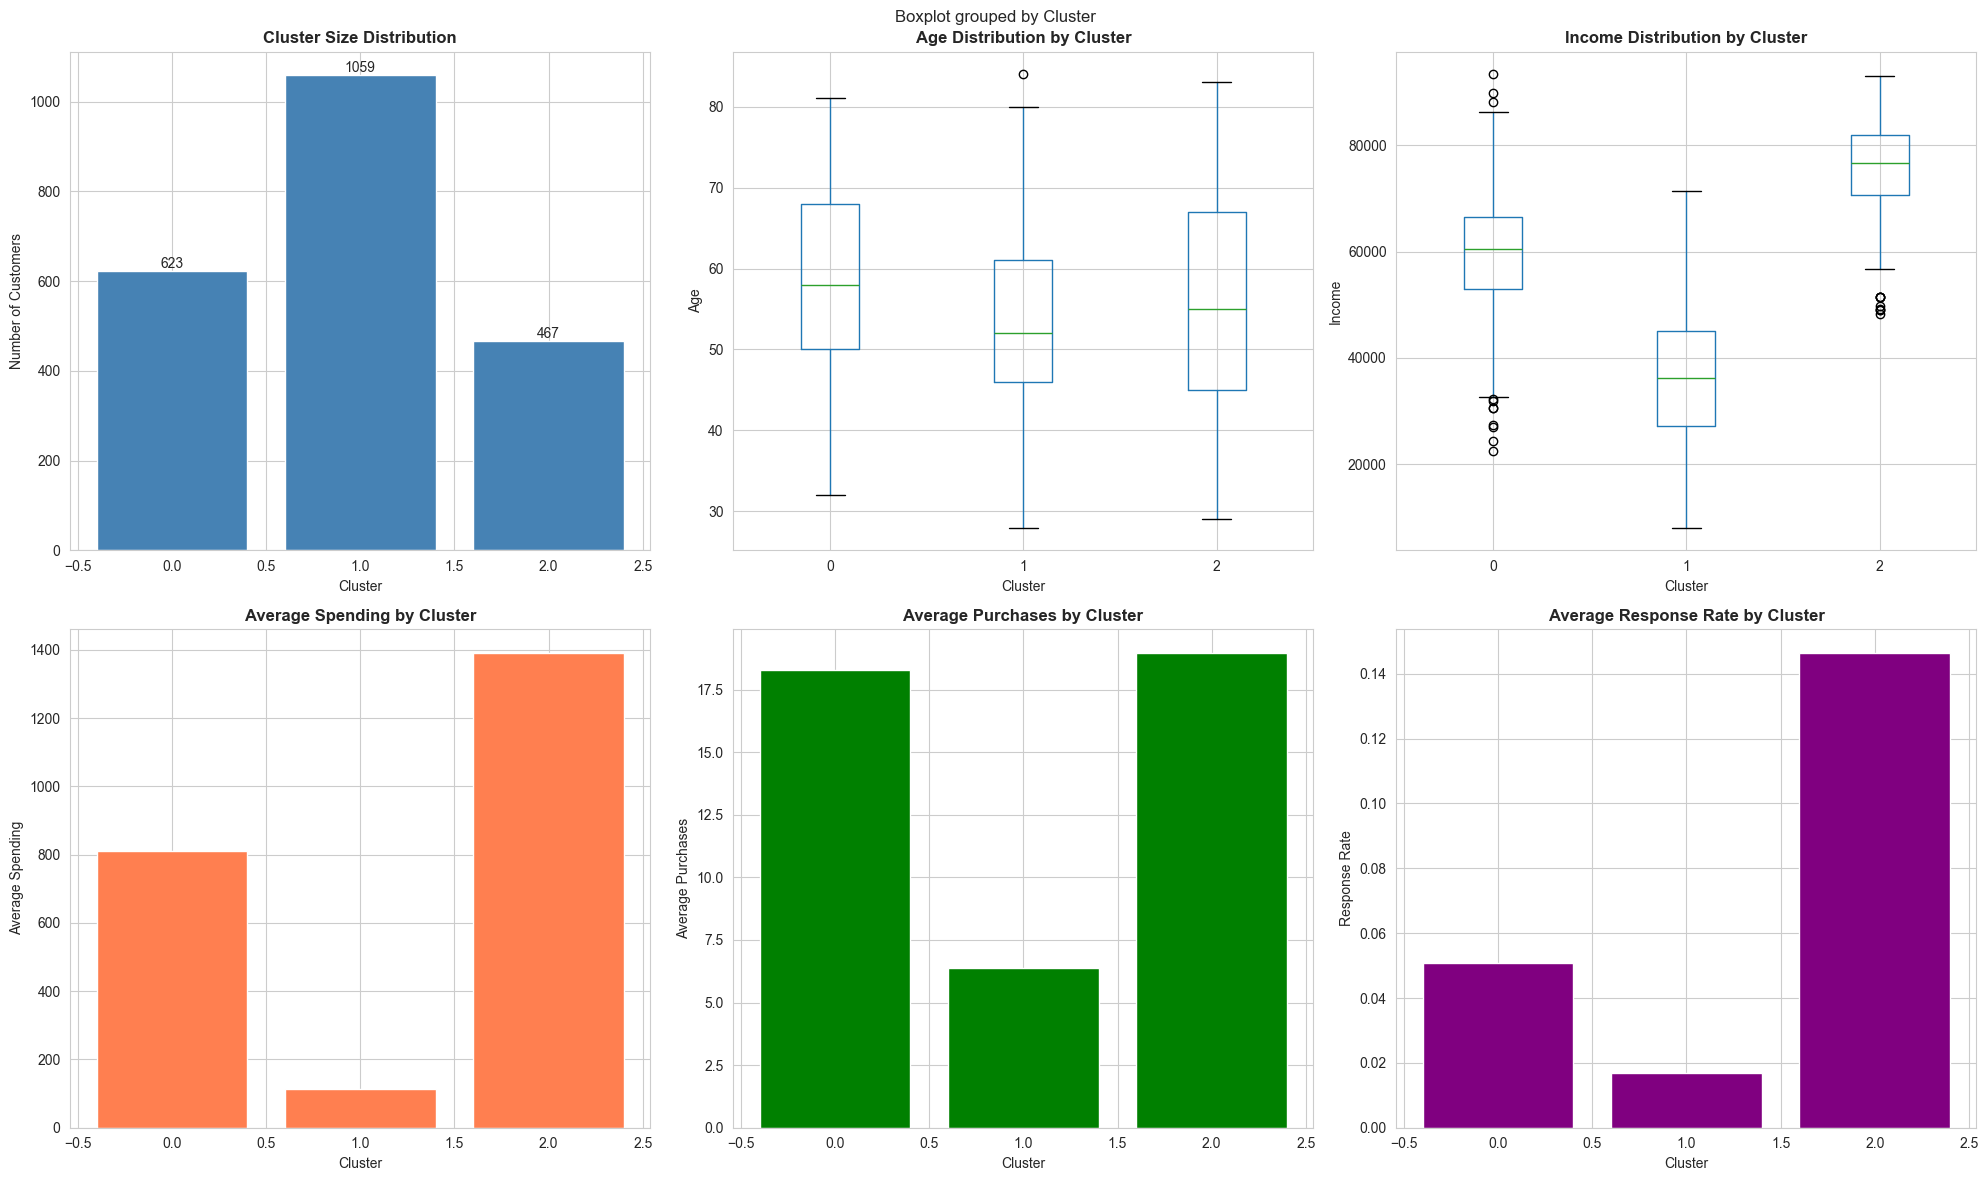

In [19]:
# Create comprehensive cluster overview
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Customer Segment Overview Dashboard', fontsize=16, fontweight='bold')

# 1. Cluster Size Distribution
cluster_counts = df['Cluster'].value_counts().sort_index()
axes[0, 0].bar(cluster_counts.index, cluster_counts.values, color='steelblue')
axes[0, 0].set_title('Cluster Size Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Number of Customers')
for i, v in enumerate(cluster_counts.values):
    axes[0, 0].text(cluster_counts.index[i], v, str(v), ha='center', va='bottom')

# 2. Age Distribution by Cluster
df.boxplot(column='Age', by='Cluster', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Cluster', fontweight='bold')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Age')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# 3. Income Distribution by Cluster
df.boxplot(column='Income', by='Cluster', ax=axes[0, 2])
axes[0, 2].set_title('Income Distribution by Cluster', fontweight='bold')
axes[0, 2].set_xlabel('Cluster')
axes[0, 2].set_ylabel('Income')
plt.sca(axes[0, 2])
plt.xticks(rotation=0)

# 4. Average Spending by Cluster
spending_by_cluster = df.groupby('Cluster')['Total_Spending'].mean()
axes[1, 0].bar(spending_by_cluster.index, spending_by_cluster.values, color='coral')
axes[1, 0].set_title('Average Spending by Cluster', fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Average Spending')

# 5. Total Purchases by Cluster
purchases_by_cluster = df.groupby('Cluster')['Total_Purchases'].mean()
axes[1, 1].bar(purchases_by_cluster.index, purchases_by_cluster.values, color='green')
axes[1, 1].set_title('Average Purchases by Cluster', fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Average Purchases')

# 6. Response Rate by Cluster
response_by_cluster = df.groupby('Cluster')['Response_Rate'].mean()
axes[1, 2].bar(response_by_cluster.index, response_by_cluster.values, color='purple')
axes[1, 2].set_title('Average Response Rate by Cluster', fontweight='bold')
axes[1, 2].set_xlabel('Cluster')
axes[1, 2].set_ylabel('Response Rate')

plt.tight_layout()
plt.show()

## 4.2 Product Preferences by Cluster

<Figure size 1400x800 with 0 Axes>

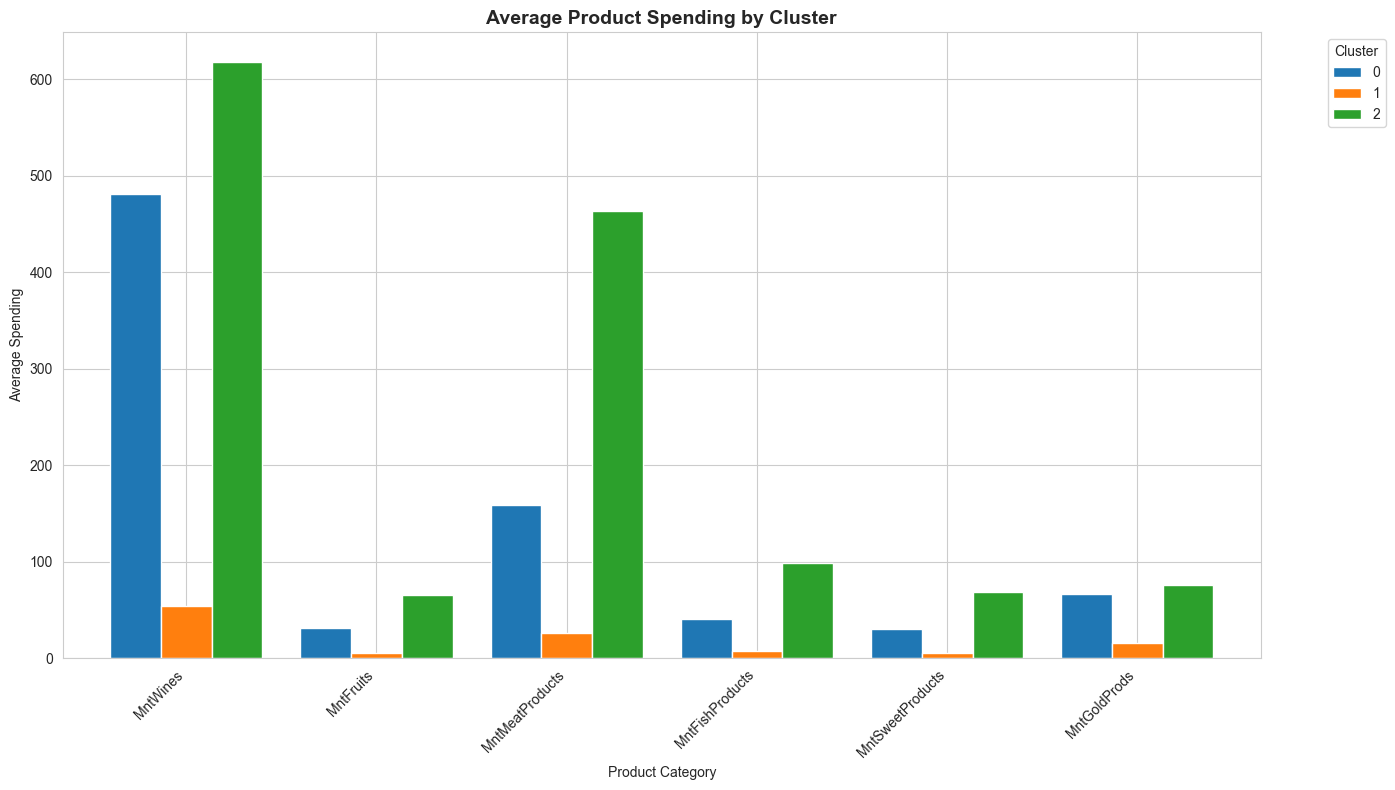

In [20]:
# Analyze product preferences
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
               'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

product_by_cluster = df.groupby('Cluster')[product_cols].mean()

# Plot
plt.figure(figsize=(14, 8))
product_by_cluster.T.plot(kind='bar', figsize=(14, 8), width=0.8)
plt.title('Average Product Spending by Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Average Spending')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4.3 Customer Behavior Analysis

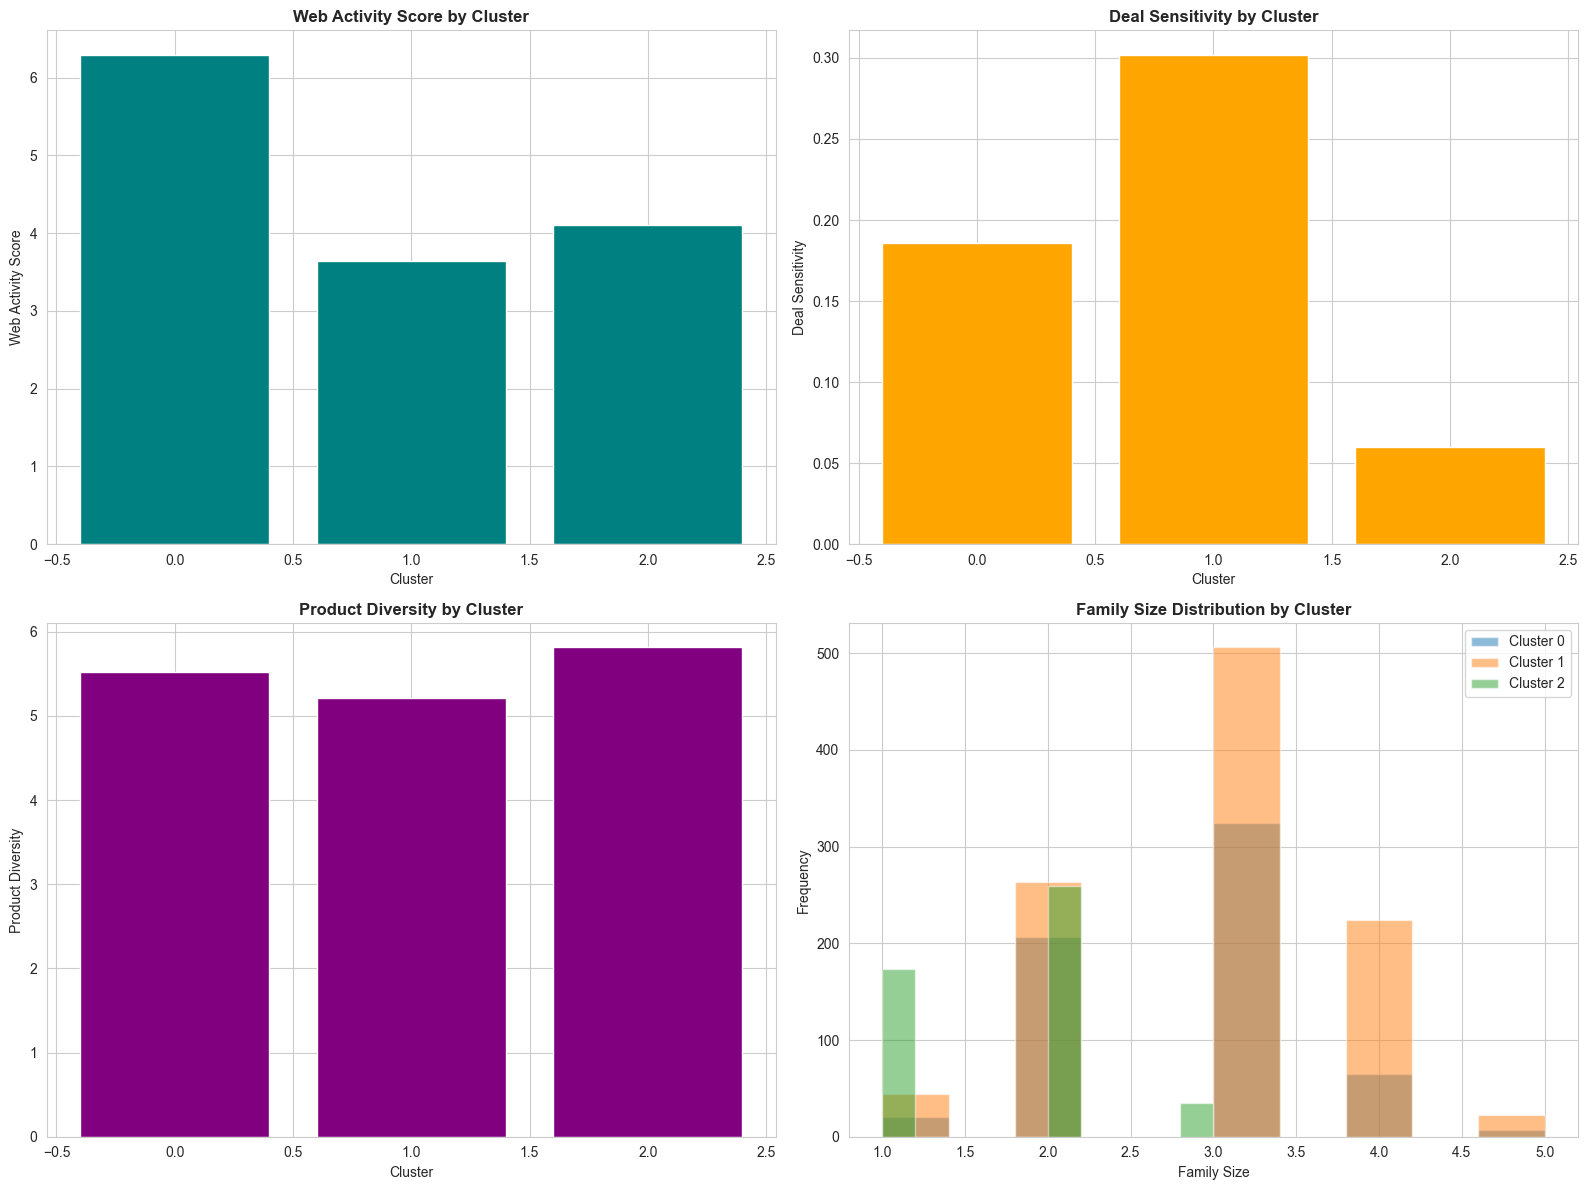

In [21]:
# Analyze customer behavior patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Web Activity by Cluster
web_activity = df.groupby('Cluster')['Web_Activity_Score'].mean()
axes[0, 0].bar(web_activity.index, web_activity.values, color='teal')
axes[0, 0].set_title('Web Activity Score by Cluster', fontweight='bold')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Web Activity Score')

# 2. Deal Sensitivity by Cluster
deal_sensitivity = df.groupby('Cluster')['Deal_Sensitivity'].mean()
axes[0, 1].bar(deal_sensitivity.index, deal_sensitivity.values, color='orange')
axes[0, 1].set_title('Deal Sensitivity by Cluster', fontweight='bold')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Deal Sensitivity')

# 3. Product Diversity by Cluster
product_diversity = df.groupby('Cluster')['Product_Diversity'].mean()
axes[1, 0].bar(product_diversity.index, product_diversity.values, color='purple')
axes[1, 0].set_title('Product Diversity by Cluster', fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Product Diversity')

# 4. Family Size Distribution by Cluster
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]['Family_Size']
    axes[1, 1].hist(cluster_data, alpha=0.5, label=f'Cluster {cluster}', bins=10)
axes[1, 1].set_title('Family Size Distribution by Cluster', fontweight='bold')
axes[1, 1].set_xlabel('Family Size')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 4.4 Interactive 3D Cluster Visualization

In [22]:
# Create 3D visualization using Plotly
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

df_3d = pd.DataFrame({
    'PC1': X_3d[:, 0],
    'PC2': X_3d[:, 1],
    'PC3': X_3d[:, 2],
    'Cluster': df['Cluster'].astype(str),
    'Income': df['Income'],
    'Spending': df['Total_Spending']
})

fig = px.scatter_3d(df_3d, x='PC1', y='PC2', z='PC3', 
                    color='Cluster',
                    hover_data=['Income', 'Spending'],
                    title='3D Customer Segmentation Visualization',
                    labels={'PC1': f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})',
                           'PC2': f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})',
                           'PC3': f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})'})

fig.update_traces(marker=dict(size=4))
fig.show()

## 4.5 Correlation Analysis

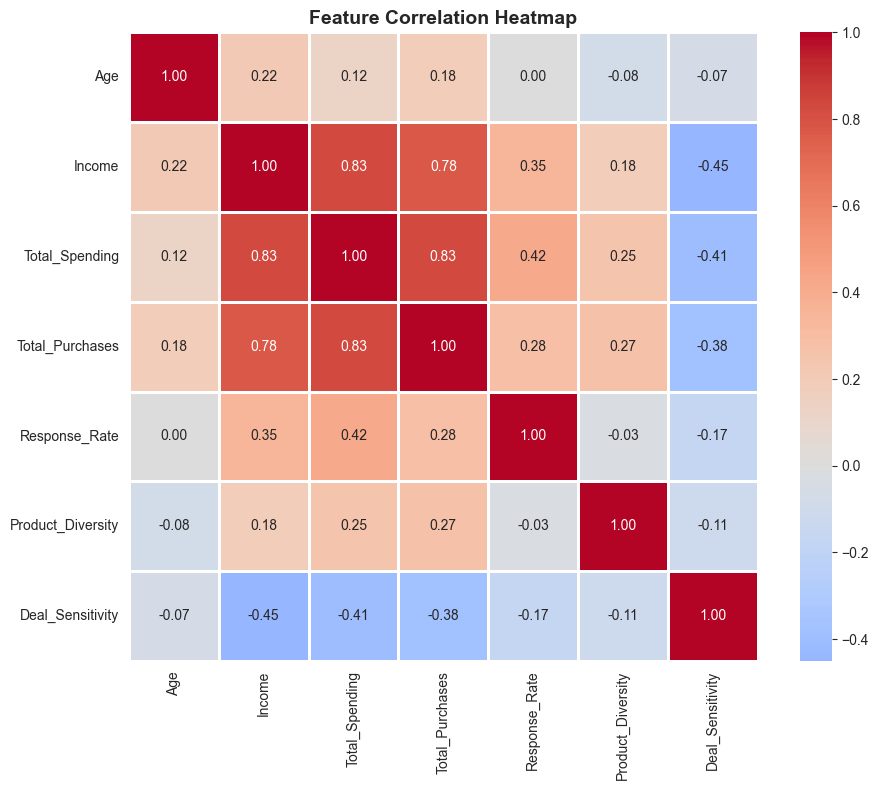

In [23]:
# Correlation heatmap of key features
key_features = ['Age', 'Income', 'Total_Spending', 'Total_Purchases', 
               'Response_Rate', 'Product_Diversity', 'Deal_Sensitivity']

correlation_matrix = df[key_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
           center=0, square=True, linewidths=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Summary & Conclusions
---

## Key Findings

### Data Preprocessing
- Successfully handled missing values and created 17 new engineered features
- Removed outliers to improve data quality
- Final dataset ready for machine learning

### Clustering Analysis
- Identified optimal number of customer segments using multiple evaluation metrics
- K-Means clustering provided clear customer segmentation
- Each cluster shows distinct characteristics in terms of spending, demographics, and behavior

### Classification Models
- Trained and compared 6 different classification algorithms
- Best performing model achieved high accuracy in predicting customer segments
- Feature importance analysis revealed key drivers of customer segmentation

### Business Insights
- Different customer segments show varying levels of engagement and spending patterns
- Product preferences differ significantly across clusters
- Response rates to campaigns vary by segment, enabling targeted marketing

## Next Steps
1. Deploy the best classification model for real-time customer segmentation
2. Develop targeted marketing strategies for each customer segment
3. Monitor segment evolution over time
4. A/B test personalized campaigns for different segments
5. Integrate insights into CRM systems

---
**Analysis Complete!** 🎉
